In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from ensemble_model import EnsembleModel
import joblib

## 1. Load the Dataset

The Dataset contains one row per completed match.

Each row contains:
- the final match outcome('team0_won')
- aggreagted statistics for both teams
- statistics for each of the six players on each team
- hero an lane assignment

Statistics measured at the 5-minute snapshot.

## 2. Feature Engineering

The engineered features fall into several groups:

### Team compositions and distributions
- Carry share
- Networth standart deviation
- Richest player relative to team avarage

### Team performance
- Team kill/death ratio (KDR)

### Team-to-team differences
- Networth difference
- Damage difference
- Avarage level difference
- Carry networth difference
- KDR difference
- Gold-per-minute difference
- Objective damage difference

### Relative ratios
- Networth ratio
- Damage ratio
- Objective damage ratio

In [ ]:
df = pd.read_csv("YOUR_PATH_HERE")

new_features = pd.DataFrame({
    "team0_carry_share" : (df["team0_p1_networth"]/df["team0_team_total_networth"]),
    "team1_carry_share" : (df["team1_p1_networth"]/df["team1_team_total_networth"]),
    "team0_networth_std" : df[["team0_p1_networth","team0_p2_networth","team0_p3_networth","team0_p4_networth","team0_p5_networth","team0_p6_networth"]].std(axis=1),
    "team1_networth_std" : df[["team1_p1_networth","team1_p2_networth","team1_p3_networth","team1_p4_networth","team1_p5_networth","team1_p6_networth"]].std(axis=1),
    "team0_team_kdr" : (df["team0_team_total_kills"]/(df["team0_team_total_deaths"]+1)),
    "team1_team_kdr" : (df["team1_team_total_kills"]/(df["team1_team_total_deaths"]+1)),
    "team0_richest_vs_team_avg" : (df["team0_p1_networth"]/(df["team0_team_total_networth"]/6)),
    "team1_richest_vs_team_avg" : (df["team1_p1_networth"]/(df["team1_team_total_networth"]/6)),
    'networth_diff': df['team0_team_total_networth'] - df['team1_team_total_networth'],
    "damage_diff":df["team0_team_total_damage"]-df["team1_team_total_damage"],
    "level_diff":df["team0_team_avg_level"]-df["team1_team_avg_level"],
    "carry_diff":df["team0_p1_networth"] - df["team1_p1_networth"],
    "kdr_diff":(df["team0_team_total_kills"]/(df["team0_team_total_deaths"]+1))-(df["team1_team_total_kills"]/(df["team1_team_total_deaths"]+1)),
    "gpm_diff" : (df["team0_team_gold_per_minute"]-df["team1_team_gold_per_minute"]),
    "objective_diff" : (df["team0_team_total_objectivedamage"]-df["team1_team_total_objectivedamage"]),
    "networth_ratio" : (df["team0_team_total_networth"]/(df["team1_team_total_networth"]+1)),
    "damage_ratio" : (df["team0_team_total_damage"]/(df["team1_team_total_damage"]+1)),
    "objective_ratio" : (df["team0_team_total_objectivedamage"]/(df["team1_team_total_objectivedamage"]+1))
})
df = pd.concat([df, new_features],axis=1)
print(df.shape)
df


(18492, 202)


,match_id,team0_won,team0_team_total_kills,team0_team_total_deaths,team0_team_total_networth,team0_team_total_damage,team0_team_total_objectivedamage,team0_team_avg_level,team0_team_gold_per_minute,team0_p1_hero,...,networth_diff,damage_diff,level_diff,carry_diff,kdr_diff,gpm_diff,objective_diff,networth_ratio,damage_ratio,objective_ratio
0,1883785,0,1,12,13887,8466,28,5.666667,385.749936,15,...,-10917,-4850,-1.500000,-2282,-3.923077,-303.249949,-5558,0.559847,0.635729,0.005012
1,1894783,1,7,6,19112,10496,1565,6.500000,530.888800,2,...,918,2310,0.333333,488,0.500000,25.499996,375,1.050398,1.282032,1.314022
2,30579330,0,11,1,23988,11508,2719,8.000000,666.333222,3,...,5869,-3130,1.333333,2273,5.423077,163.027751,2567,1.323841,0.786119,17.771242
3,1741000,1,3,3,17747,12237,4104,6.666667,492.972140,2,...,1659,1911,1.000000,-857,0.150000,46.083326,3843,1.103052,1.184952,15.664122
4,38984295,1,10,2,29172,17575,1511,8.333333,810.333198,3,...,5258,9948,1.000000,1313,3.242424,146.055531,689,1.219820,2.304012,1.835966
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18487,83271376,1,11,7,27046,18222,1351,7.666667,751.277653,1,...,2999,517,0.666667,686,0.836538,83.305542,1236,1.124667,1.029143,11.646552
18488,83270998,1,6,2,24477,15565,681,7.000000,679.916553,13,...,1707,1460,0.333333,320,1.714286,47.416659,-124,1.074920,1.103431,0.844913
18489,83272008,0,1,4,21453,12486,83,6.333333,595.916567,79,...,-1929,-1673,-0.500000,-166,-1.800000,-53.583324,-3497,0.917461,0.881780,0.023178
18490,83271597,1,6,4,24710,14642,352,7.166667,686.388774,77,...,1145,184,0.166667,332,0.628571,31.805550,237,1.048545,1.012656,3.034483


In [15]:
all_hero_ids = np.sort(df["team0_p1_hero"].unique())
all_lane_ids = np.sort(df["team0_p1_lane"].unique())
print('All hero ids', all_hero_ids)
print('All lanes', all_lane_ids)

All hero ids [ 1  2  3  4  6  7  8 10 11 12 13 14 15 16 17 18 19 20 25 27 31 35 50 52
 58 60 63 64 65 66 67 69 72 76 77 79 80 81]
All lanes [1 3 4 6]


## 3. Train/Test Split

The data is split into 80% training and 20% test data

In [ ]:
X = df.drop(columns=["team0_won","match_id"])

y = df["team0_won"]

categorical_columns = []
for team in [0,1]:
    for i in range(1,7):
        categorical_columns.append(f'team{team}_p{i}_hero')
        categorical_columns.append(f'team{team}_p{i}_lane')

X = pd.get_dummies(X, columns=categorical_columns)
feature_columns = joblib.load("YOUR_PATH_HERE")
X = X.reindex(columns=feature_columns, fill_value=0)
print(X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X.columns.to_list()

(18492, 679)


['team0_team_total_kills',
 'team0_team_total_deaths',
 'team0_team_total_networth',
 'team0_team_total_damage',
 'team0_team_total_objectivedamage',
 'team0_team_avg_level',
 'team0_team_gold_per_minute',
 'team0_p1_kills',
 'team0_p1_deaths',
 'team0_p1_assists',
 'team0_p1_networth',
 'team0_p1_damage',
 'team0_p1_creeps',
 'team0_p1_level',
 'team0_p1_objective_damage',
 'team0_p1_denies',
 'team0_p1_gold_per_minute',
 'team0_p1_player_healing',
 'team0_p1_self_healing',
 'team0_p2_kills',
 'team0_p2_deaths',
 'team0_p2_assists',
 'team0_p2_networth',
 'team0_p2_damage',
 'team0_p2_creeps',
 'team0_p2_level',
 'team0_p2_objective_damage',
 'team0_p2_denies',
 'team0_p2_gold_per_minute',
 'team0_p2_player_healing',
 'team0_p2_self_healing',
 'team0_p3_kills',
 'team0_p3_deaths',
 'team0_p3_assists',
 'team0_p3_networth',
 'team0_p3_damage',
 'team0_p3_creeps',
 'team0_p3_level',
 'team0_p3_objective_damage',
 'team0_p3_denies',
 'team0_p3_gold_per_minute',
 'team0_p3_player_healing'

## 4. Baseline Performance

As an initial benchmark, an XGB classifier and RandomForest classifier are trained with a relatively simple configurations.

The baseline models achive roughly 64% test accuracy

In [ ]:
model_xgb = XGBClassifier(n_estimators=300,max_depth=3,learning_rate=0.05,random_state=42)
model_xgb.fit(X_train, y_train)
predictions = model_xgb.predict(X_test)

accuracy_xgb = accuracy_score(y_test, predictions)
print(f"Accuracy for XGB: {accuracy_xgb}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy for XGB: 0.644228169775615

Classification Report:

              precision    recall  f1-score   support

           0       0.64      0.64      0.64      1836
           1       0.65      0.65      0.65      1863

    accuracy                           0.64      3699
   macro avg       0.64      0.64      0.64      3699
weighted avg       0.64      0.64      0.64      3699



In [18]:
importance = pd.DataFrame({"feature": X.columns, "importance": model_xgb.feature_importances_})

importance = importance.sort_values(by="importance",ascending=False)

importance

,feature,importance
173,networth_ratio,0.050807
166,networth_diff,0.034703
167,damage_diff,0.012249
174,damage_ratio,0.011773
172,objective_diff,0.008360
...,...,...
653,team1_p6_hero_19,0.000000
654,team1_p6_hero_20,0.000000
655,team1_p6_hero_25,0.000000
245,team0_p2_hero_64,0.000000


In [ ]:
model_rf = RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42)

model_rf.fit(X_train, y_train)

rf_predictions = model_rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy}")

print("\n Random Forest Report:")

print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.6320627196539605

Random Forest Report:

              precision    recall  f1-score   support

           0       0.63      0.63      0.63      1836
           1       0.63      0.64      0.64      1863

    accuracy                           0.63      3699
   macro avg       0.63      0.63      0.63      3699
weighted avg       0.63      0.63      0.63      3699



In [20]:
rf_importance = pd.DataFrame({"feature": X.columns,"importance": model_rf.feature_importances_})

rf_importance = rf_importance.sort_values(by="importance",ascending=False)

print(rf_importance.head(20))

                              feature  importance
166                     networth_diff    0.031776
173                    networth_ratio    0.028447
171                          gpm_diff    0.019647
174                      damage_ratio    0.019464
167                       damage_diff    0.019145
168                        level_diff    0.017025
172                    objective_diff    0.015604
175                   objective_ratio    0.013848
162                    team0_team_kdr    0.013222
170                          kdr_diff    0.012845
2           team0_team_total_networth    0.012661
6          team0_team_gold_per_minute    0.011947
163                    team1_team_kdr    0.011767
169                        carry_diff    0.011232
85         team1_team_gold_per_minute    0.010837
81          team1_team_total_networth    0.010369
58                  team0_p5_networth    0.010104
83   team1_team_total_objectivedamage    0.009783
64           team0_p5_gold_per_minute    0.009576


## 5. Tuned XGBoost

The next experiment uses a more regularized XGBoost configuration.

In [ ]:
model_xgb = XGBClassifier(

    n_estimators=500,

    max_depth=4,

    learning_rate=0.03,

    subsample=0.7,

    colsample_bytree=0.7,

    min_child_weight=7,

    gamma=2,

    reg_alpha=2,

    reg_lambda=10,

    random_state=42,
)
model_xgb.fit(X_train, y_train)
predictions = model_xgb.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy for XGB: {accuracy}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy for XGB: 0.6450391997837254

Classification Report:

              precision    recall  f1-score   support

           0       0.64      0.64      0.64      1836
           1       0.65      0.65      0.65      1863

    accuracy                           0.65      3699
   macro avg       0.65      0.65      0.65      3699
weighted avg       0.65      0.65      0.65      3699



The tuned model achives ~64.5% test accuracy and ~72.4% train accuracy

In [ ]:
train_acc = model_xgb.score(X_train, y_train)

test_acc = model_xgb.score(X_test, y_test)

print(train_acc)
print(test_acc)

0.724329074562293
0.6450391997837254


### 6. ROC-AUC

Because the final application outputs a win probability rather than only a binary prediction, accuracy alone is not sufficient.

ROC-AUC measures how well the model ranks winning teams above losing teams across different probability thresholds.

For the tuned XGBoost model, the test ROC-AUC is approximately 0.696.

In [ ]:
from sklearn.metrics import roc_auc_score

probs=model_xgb.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test,probs))


0.696142603877598


## 7. CatBoost

CatBoost is evaluated as a second gradient-boosting model.

It recieves approximately 64% test accuracy and 0.694 ROC-AUC score.

In [ ]:
model_cat = CatBoostClassifier(

    iterations=1500,

    depth=4,

    learning_rate=0.02,

    l2_leaf_reg=15,

    min_data_in_leaf=30,

    random_strength=5,

    bagging_temperature=2,

    verbose=100,

    random_seed=42
)

model_cat.fit(X_train, y_train)

probs = model_cat.predict_proba(X_test)[:,1]

predictions = model_cat.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy for CAT: {accuracy}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

pred=(probs>0.5)

print(accuracy_score(y_test, pred))

print(roc_auc_score(y_test, probs))

0:	learn: 0.6919965	total: 9.28ms	remaining: 13.9s
100:	learn: 0.6522682	total: 1.11s	remaining: 15.4s
200:	learn: 0.6453849	total: 1.92s	remaining: 12.4s
300:	learn: 0.6417644	total: 2.77s	remaining: 11.1s
400:	learn: 0.6390544	total: 3.66s	remaining: 10s
500:	learn: 0.6359596	total: 4.53s	remaining: 9.03s
600:	learn: 0.6306794	total: 5.48s	remaining: 8.2s
700:	learn: 0.6235325	total: 6.41s	remaining: 7.3s
800:	learn: 0.6164715	total: 7.26s	remaining: 6.34s
900:	learn: 0.6097283	total: 8.04s	remaining: 5.35s
1000:	learn: 0.6033235	total: 8.79s	remaining: 4.38s
1100:	learn: 0.5971373	total: 9.75s	remaining: 3.53s
1200:	learn: 0.5910089	total: 10.6s	remaining: 2.65s
1300:	learn: 0.5851444	total: 11.5s	remaining: 1.76s
1400:	learn: 0.5794874	total: 12.4s	remaining: 873ms
1499:	learn: 0.5741027	total: 13.2s	remaining: 0us
Accuracy for CAT: 0.6401730197350636

Classification Report:

              precision    recall  f1-score   support

           0       0.64      0.64      0.64      183

In [ ]:
train_acc = model_cat.score(X_train, y_train)

test_acc = model_cat.score(X_test, y_test)

print(train_acc)
print(test_acc)

0.7086459812073278
0.6401730197350636


## 8. Ensemble Model

The final predictor combines the XGBoost and CatBoost models using simple soft-voting ensemble. For each match, both models produce class probabilities, which are then avaraged using arithmetic mean.

On the test set ensemble achieves approxiamtely 64.4% accuracy and 0.696 ROC-AUC score.

In [ ]:
ensemble = EnsembleModel(model_xgb, model_cat)
joblib.dump(ensemble, 'YOUR_PATH_HERE')

pred = ensemble.predict(X_test)
probs = ensemble.predict_proba(X_test)

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

print(accuracy_score(y_test, pred))

print(roc_auc_score(y_test, probs[:, 1]))

0.6439578264395782
0.6961988827259896


## 9. Calibration Curve

A calibration curve compares predicted probabilities with the observed frequency of the positive class.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

calibrated = CalibratedClassifierCV(model_xgb, method='isotonic',cv=5)

calibrated.fit(X_train,y_train)

probs = calibrated.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test,probs))

0.6949275654676494


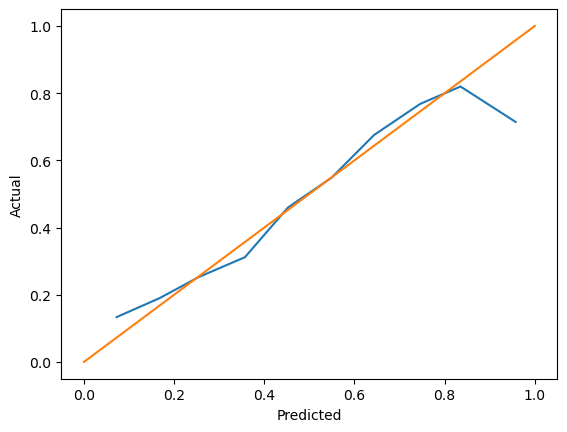

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

plt.plot(prob_pred, prob_true)

plt.plot([0,1], [0,1])

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## 10. Model Explainability with SHAP

SHAP is used to investigate which features influence the XGBoost predictions.

Two visualizations are produced:

1. A SHAP summary plot showing the overall importance and direction of feature contributions.
2. A bar plot showing aggregated feature importance.

This provides an interpretable view of which aspects of the game influance the model prediction the most.

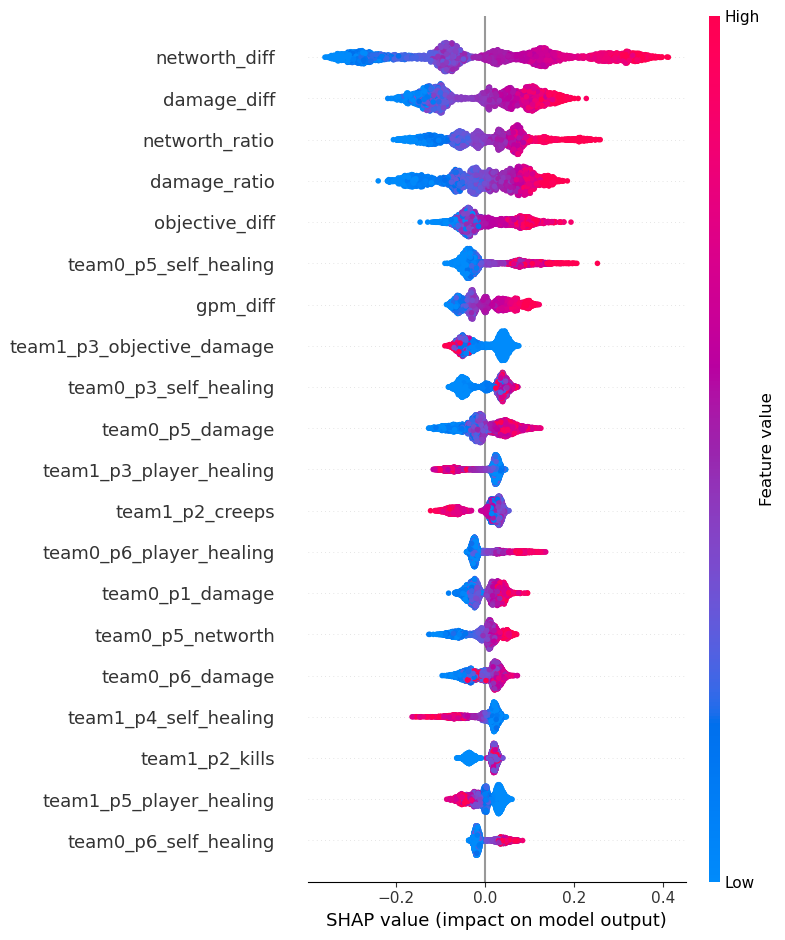

In [ ]:
import shap

explainer = shap.TreeExplainer(model_xgb)

shap_values = (explainer.shap_values(X_test))

shap.summary_plot(shap_values, X_test)

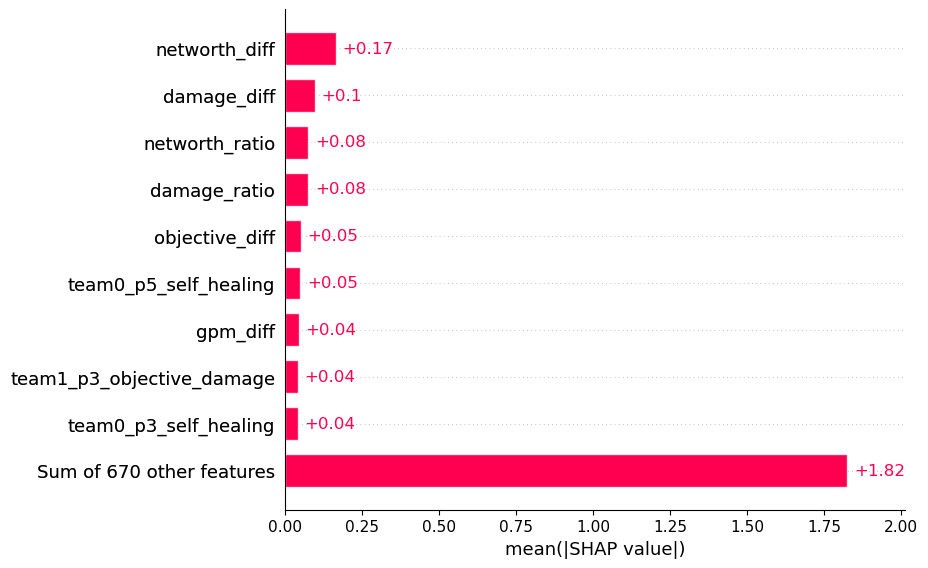

In [ ]:
shap.plots.bar(shap.Explanation(values=shap_values, data=X_test.values, feature_names=X_test.columns))